In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shamik777","key":"821f0db681fc008e84191731e32d5135"}'}

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/

In [3]:
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!pip install kaggle

In [5]:
!kaggle datasets list

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                               Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           7614        180                1  
nalisha/job-salary-prediction-dataset                        Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13762        309                1  
meruvakodandasuraj/youtube-trending-videos-20202026          YouTube Trending Videos 2020–2026                       843930  2026-04-13 11:10:04.770000            555         27                1  
mubashirsidiki/

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset files: /kaggle/input/lgg-mri-segmentation


In [7]:
! pip install torchview

In [8]:
!pip install torchinfo

In [9]:
from torchinfo import summary

In [10]:
from torchview import draw_graph

In [11]:
import random
import os
import glob
import time
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torchvision
import torch.optim.lr_scheduler as lr_scheduler

from torch import nn
from torch.utils.data import (Dataset, DataLoader)
from torchvision import transforms
from torchinfo import summary
from torchview import draw_graph

import albumentations as A
from albumentations.pytorch import ToTensorV2

from PIL import Image
from tqdm.notebook import tqdm
from typing import Dict, List, Tuple

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, precision_recall_fscore_support,
    accuracy_score, f1_score, matthews_corrcoef,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.style.use("dark_background")

In [12]:
class CFG:
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    NUM_DEVICES = torch.cuda.device_count()
    NUM_WORKERS = os.cpu_count()

    NUM_CLASSES = 2
    EPOCHS = 100
    BATCH_SIZE = (
        32 if torch.cuda.device_count() < 2
        else (32 * torch.cuda.device_count())
    )
    LR = 1e-4
    PATIENS = 8

    APPLY_SHUFFLE = True
    SEED = 768
    HEIGHT = 224
    WIDTH = 224
    CHANNELS = 3
    IMAGE_SIZE = (224, 224, 3)

    # Define paths
    DATASET_PATH = "/kaggle/input/lgg-mri-segmentation/"
    TRAIN_PATH = '/kaggle/input/lgg-mri-segmentation/kaggle_3m/'

# Mute warnings
warnings.filterwarnings('ignore')

In [13]:
# Print current package versions
print('Package versions:')
print('*'*26)
print(f'torch \t\t - {torch.__version__}')
print(f'torchvision \t - {torchvision.__version__}')

Package versions:
**************************
torch 		 - 2.10.0+cu128
torchvision 	 - 0.25.0+cu128


In [14]:
%%time
dataset_images = glob.glob(f"{CFG.TRAIN_PATH}**/*.tif")
dataset_images[:5]

CPU times: user 20.6 ms, sys: 27.3 ms, total: 47.8 ms
Wall time: 987 ms


['/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif',
 '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif',
 '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif',
 '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif',
 '/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif']

In [15]:
def get_sample_patient_id(image_paths):
    return [(_.split('/')[-2:][0]) for _ in image_paths]


def get_sample_number(image_paths):
    sample_numbers = []
    is_mask = []

    for path in image_paths:
        path_list = path.split('/')[-2:][1].split('_')

        if 'mask.tif' in path_list:
            sample_numbers.append(int(path_list[-2]))
            is_mask.append(1)
        else:
            sample_numbers.append(int(path_list[-1].replace('.tif', '')))
            is_mask.append(0)

    return sample_numbers, is_mask


def build_df(image_paths):
    sample_numbers, mask_label = get_sample_number(image_paths)
    # Create dataframe
    df = pd.DataFrame({
        'id'        : sample_numbers,
        'patient'   : get_sample_patient_id(image_paths),
        'image_path': image_paths,
        'is_mask'   : mask_label
    })

    # Return df
    return df

In [16]:
dataset_df = (
    build_df(dataset_images)
    .sort_values(by=['id', 'patient', 'image_path'])
    .reset_index(drop=True)
)

dataset_df

,id,patient,image_path,is_mask
0,1,TCGA_CS_4941_19960909,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
1,1,TCGA_CS_4941_19960909,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1
2,1,TCGA_CS_4942_19970222,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3,1,TCGA_CS_4942_19970222,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1
4,1,TCGA_CS_4943_20000902,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
...,...,...,...,...
7853,87,TCGA_HT_A61B_19991127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1
7854,88,TCGA_HT_A61A_20000127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
7855,88,TCGA_HT_A61A_20000127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1
7856,88,TCGA_HT_A61B_19991127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0


In [17]:
# Group Samples by mask status
grouped_df = dataset_df.groupby(by='is_mask')

# Seperate Images from Masks
images_df, mask_df = (
    grouped_df.get_group(0).drop('is_mask', axis=1).reset_index(drop=True),
    grouped_df.get_group(1).drop('is_mask', axis=1).reset_index(drop=True)
)

# Rename path column in mask df
mask_df = mask_df.rename({'image_path': 'mask_path'}, axis=1)

# View mask df
mask_df

,id,patient,mask_path
0,1,TCGA_CS_4941_19960909,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,1,TCGA_CS_4942_19970222,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,1,TCGA_CS_4943_20000902,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,1,TCGA_CS_4944_20010208,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,1,TCGA_CS_5393_19990606,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
...,...,...,...
3924,86,TCGA_HT_A61B_19991127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3925,87,TCGA_HT_A61A_20000127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3926,87,TCGA_HT_A61B_19991127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3927,88,TCGA_HT_A61A_20000127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [18]:
def _load(image_path, as_tensor=True):
    image = Image.open(image_path)
    return np.array(image).astype(np.float32) / 255.


def generate_label(mask_path, load_fn):
    mask = load_fn(mask_path)
    if mask.max() > 0:
        return 1 # Brain Tumor Present
    return 0 # Normal

In [19]:
# Merge images and mask df's
ds = images_df.merge(
    mask_df,
    on=['id', 'patient'],
    how='left'
)

# Generate MRI Label
ds['diagnosis'] = [generate_label(_, _load) for _ in tqdm(ds['mask_path'])]
ds

  0%|          | 0/3929 [00:00<?, ?it/s]

,id,patient,image_path,mask_path,diagnosis
0,1,TCGA_CS_4941_19960909,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
1,1,TCGA_CS_4942_19970222,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
2,1,TCGA_CS_4943_20000902,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3,1,TCGA_CS_4944_20010208,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
4,1,TCGA_CS_5393_19990606,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
...,...,...,...,...,...
3924,86,TCGA_HT_A61B_19991127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3925,87,TCGA_HT_A61A_20000127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3926,87,TCGA_HT_A61B_19991127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0
3927,88,TCGA_HT_A61A_20000127,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0


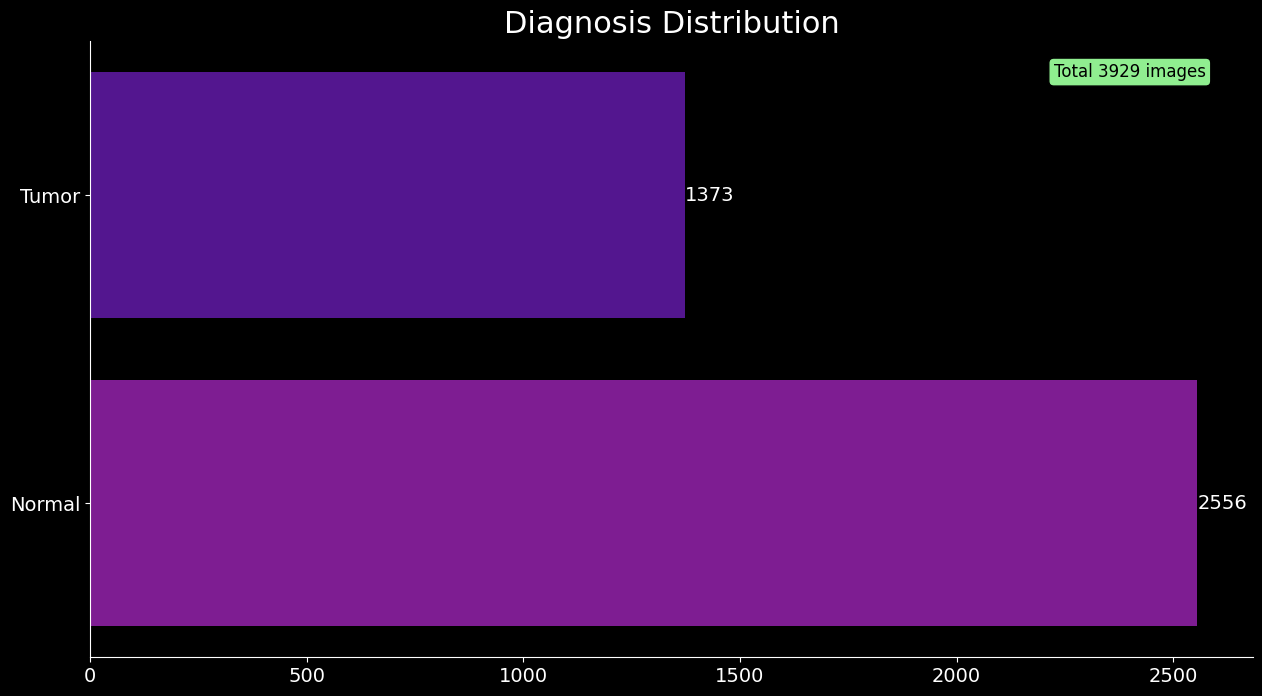

In [20]:
# View Diagnosis Distribution
fig = plt.figure(figsize=(15, 8))
plt.title('Diagnosis Distribution', fontsize=22);

diagnosis_distribution = ds['diagnosis'].value_counts().sort_values()
diagnosis_map = {0: 'Normal', 1: 'Tumor'}

bar_plot = sns.barplot(
    x=diagnosis_distribution.values,
    y=[diagnosis_map[_] for _ in diagnosis_distribution.keys()],
    palette=sns.color_palette("plasma"),
    orient="h"
);

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.0f', fontsize=14);

plt.xticks(fontsize=14);
plt.yticks(fontsize=14);

text_params = {
    'x'       : 2400,
    'y'       : -0.4,
    's'       : f"Total {len(ds)} images",
    'size'    : 12,
    'color'   : "black",
    'ha'      : "center",
    'va'      : "center",
    'bbox'    : dict(boxstyle="round", fc=("lightgreen"),ec=("black"))
}
plt.text(**text_params);

sns.despine();

In [21]:
def view_sample(image, mask, color_map='rgb', fig_size=(16, 8), title_size=18):
    fig = plt.figure(figsize=fig_size);
    fig.tight_layout();
    fig.subplots_adjust(top=0.95);

    # Plot MRI Image
    plt.subplot(1, 3, 1);
    plt.title(f'MRI Image', fontsize=title_size)
    if color_map=='rgb':
        plt.imshow(image)
    else:
        plt.imshow(image, cmap=color_map)

    # Plot Mask
    plt.subplot(1, 3, 2);
    plt.title(f'Mask', fontsize=title_size)
    plt.imshow(mask, cmap='gray');

    # Plot MRI w. Mask
    plt.subplot(1, 3, 3);
    plt.title(f'MRI + Mask', fontsize=title_size)
    gen_mask = np.dstack([mask*0.1, mask*0.4, mask*0.1])

    if color_map=='rgb':
        plt.imshow(image + gen_mask, interpolation='none')
    else:
        plt.imshow(image + gen_mask, interpolation='none', cmap=color_map)

#     plt.imshow(mask, cmap='jet', interpolation='none', alpha=0.4);

    return

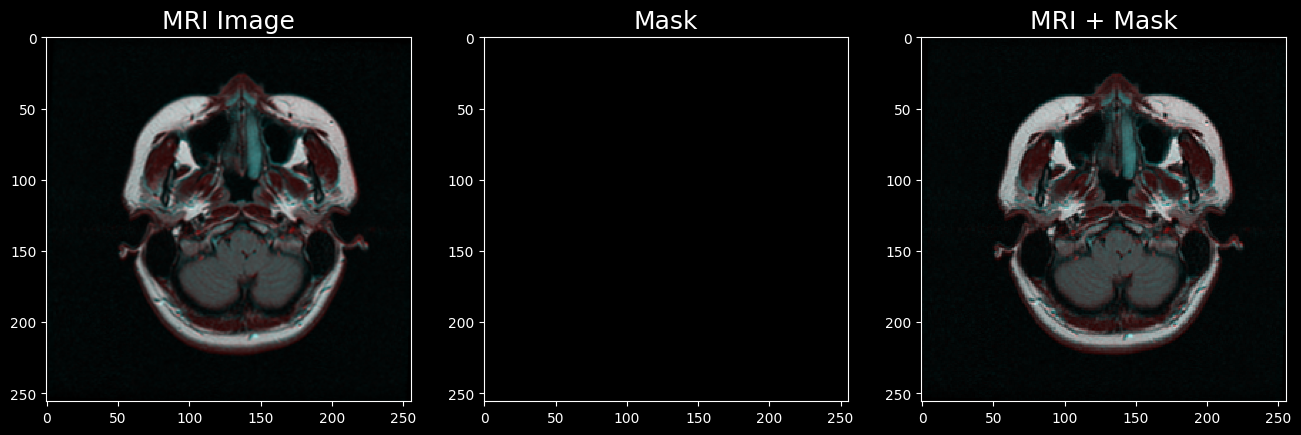

In [22]:
# Select random sample from train_df
idx = random.sample(ds.index.to_list(), 1)[0]

# Load the random sample and label
sample_image, sample_mask = _load(ds.image_path[idx]), _load(ds.mask_path[idx])

# View the random sample
view_sample(
    sample_image,
    sample_mask,
    color_map='rgb',
)

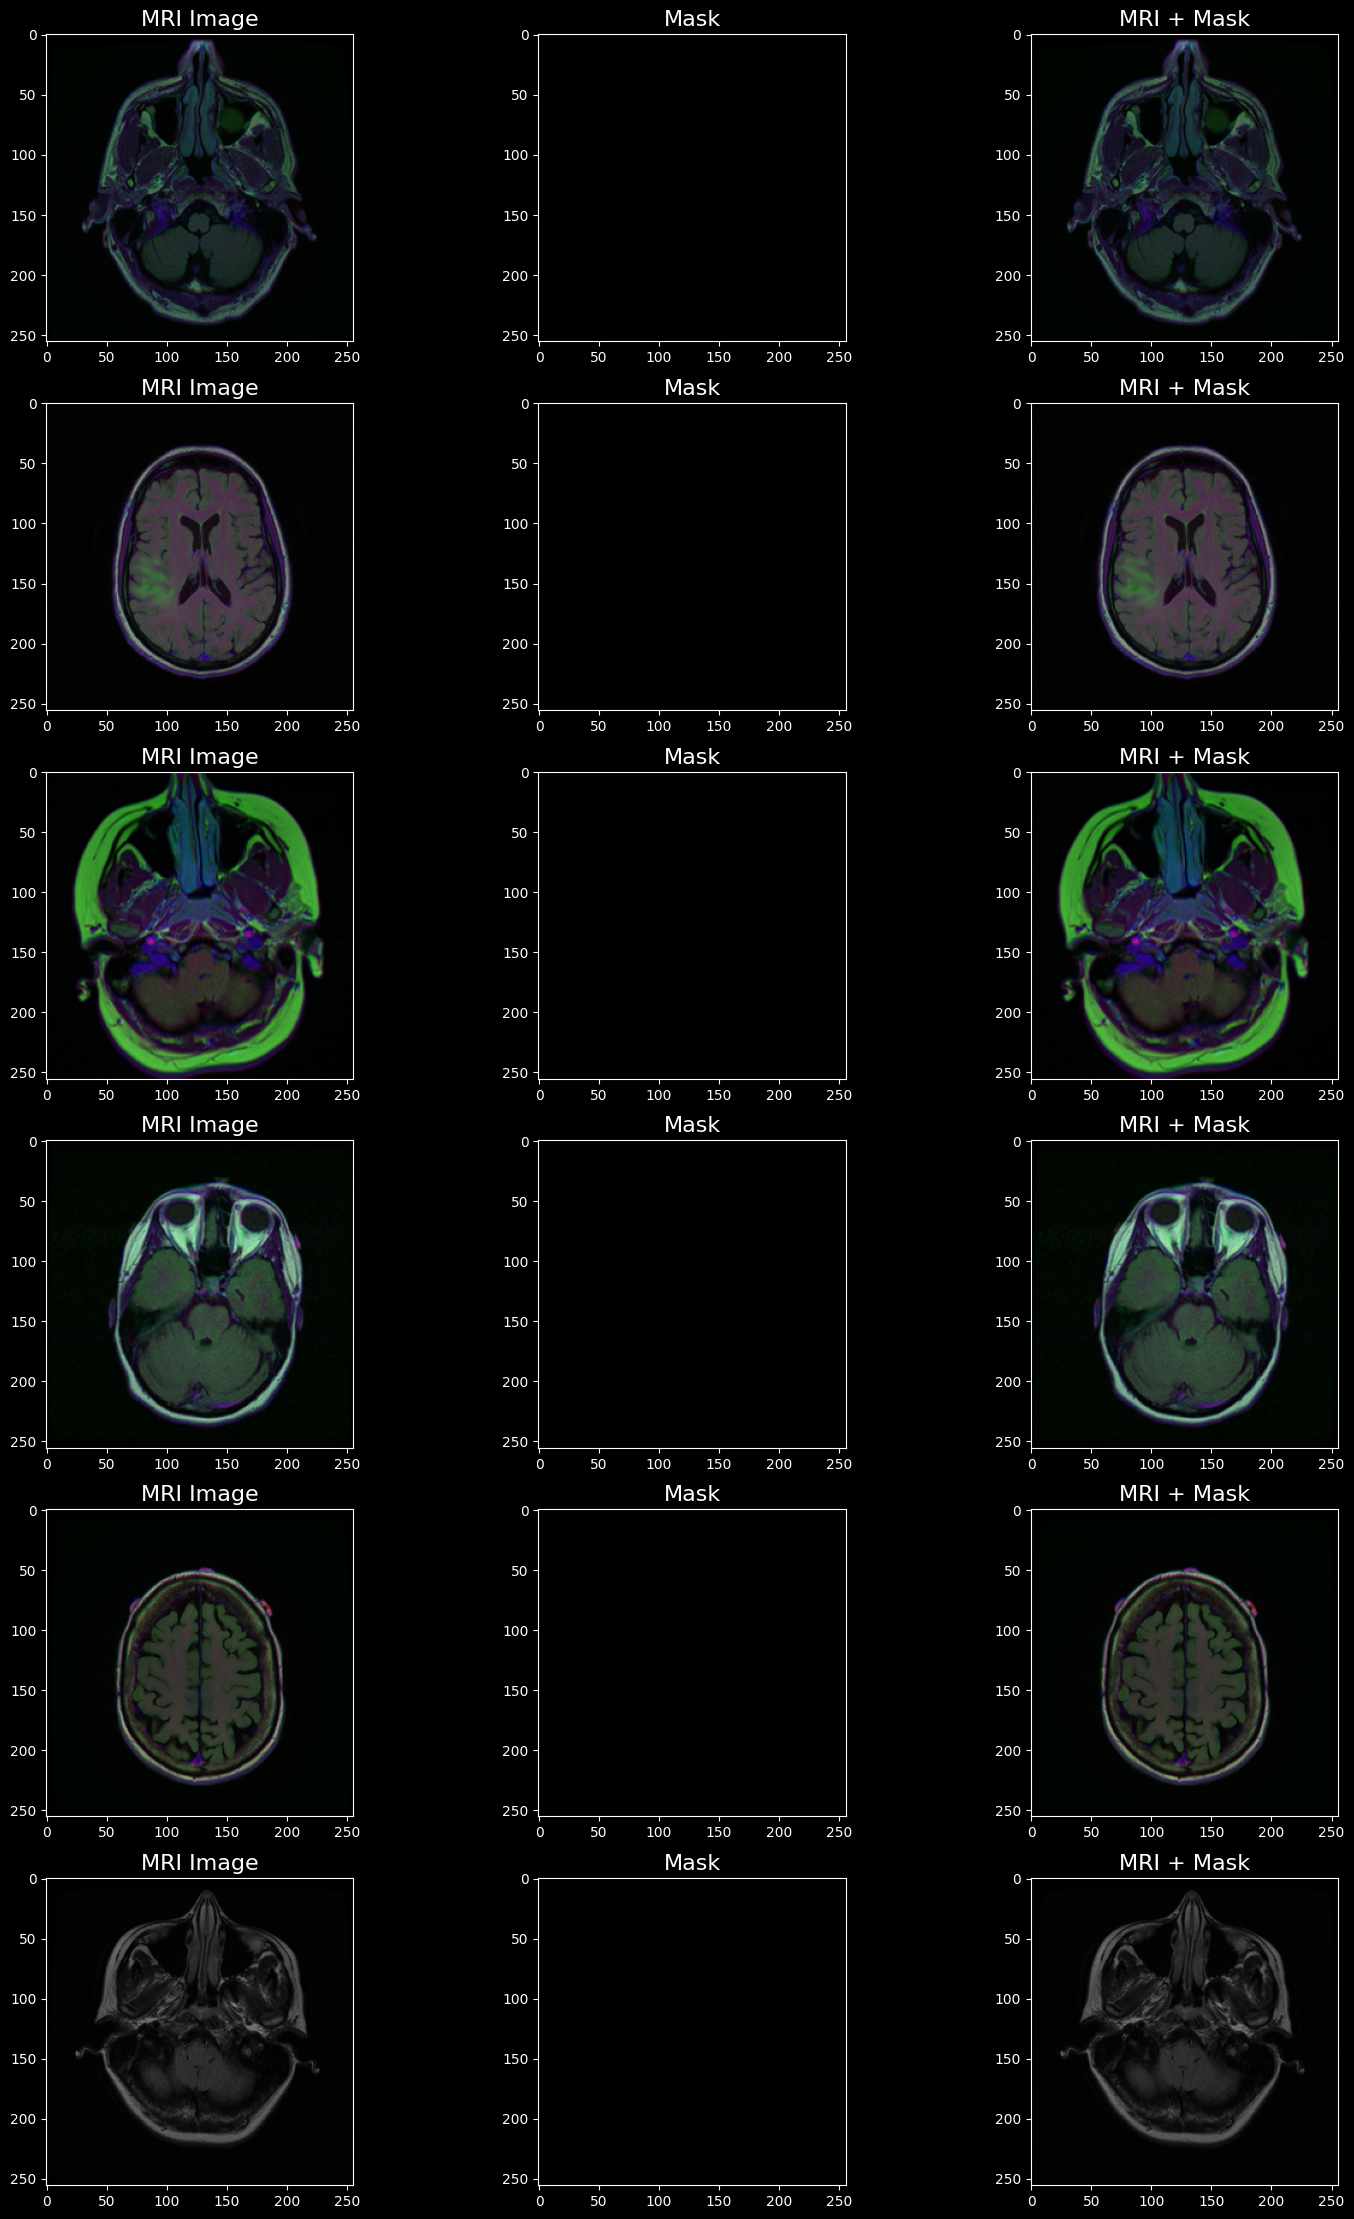

In [23]:
def view_mulitiple_samples(df, sample_loader, count=10, color_map='rgb', fig_size=(14, 10), title_size=16):
    idx = random.sample(df.index.to_list(), count)

    fig = plt.figure(figsize=fig_size);
    fig.tight_layout();
    fig.subplots_adjust(top=0.95);

    for row, _ in enumerate(idx):
        image, mask = (
            sample_loader(df.image_path[_]),#.permute(1, 2, 0),
            sample_loader(df.mask_path[_])#.permute(1, 2, 0)
        )

        idx = 3 * (row + 1)
        # Plot MRI Image
        plt.subplot(count+1, 3, idx + 1);
        plt.title(f'MRI Image', fontsize=title_size);
        if color_map=='rgb':
            plt.imshow(image)
        else:
            plt.imshow(image, cmap=color_map)

        # Plot Mask
        plt.subplot(count+1, 3, idx + 2);
        plt.title(f'Mask', fontsize=title_size)
        plt.imshow(mask, cmap='gray');

        # Plot MRI w. Mask
        plt.subplot(count+1, 3, idx + 3);
        gen_mask = np.dstack([mask*0.1, mask*0.4, mask*0.1])
        plt.title(f'MRI + Mask', fontsize=title_size)
        if color_map=='rgb':
            plt.imshow(image + gen_mask)
        else:
            plt.imshow(image + gen_mask, cmap=color_map)

#         plt.imshow(mask, cmap='gray', alpha=0.5);

    return

# View 6 random sample images
view_mulitiple_samples(
    ds, _load,
    count=6, color_map='mako',
    fig_size=(18, 30)
)

In [24]:
# Create Train split
train_split_idx, data_split_idx, _, _ = (
    train_test_split(
        ds.index,
        ds.diagnosis,
        test_size=0.30,
        stratify=ds.diagnosis,
        random_state=CFG.SEED
    )
)

# Get training and remaining data
train_df = ds.iloc[train_split_idx].reset_index(drop=True)
data_df = ds.iloc[data_split_idx].reset_index(drop=True)

# View shapes
train_df.shape, data_df.shape

((2750, 5), (1179, 5))

In [25]:
# Create Val/Test split
val_split_idx, test_split_idx, _, _ = (
    train_test_split(
        data_df.index,
        data_df.diagnosis,
        test_size=0.65,
        stratify=data_df.diagnosis,
        random_state=CFG.SEED
    )
)

# Get training and remaining data
val_df = data_df.iloc[val_split_idx].reset_index(drop=True)
test_df = data_df.iloc[test_split_idx].reset_index(drop=True)

# View shapes
val_df.shape, test_df.shape

((412, 5), (767, 5))

In [26]:
train_size = len(train_df)
val_size = len(val_df)
test_size = len(test_df)
total = train_size + val_size + test_size

# View the counts
print(f'train samples count:\t\t{train_size}\t({(100 * train_size/total):.2f}%)')
print(f'validation samples count:\t{val_size}\t({(100 * val_size/total):.2f}%)')
print(f'test samples count:\t\t{test_size}\t({(100 * test_size/total):.2f}%)')
print('================================================')
print(f'TOTAL:\t\t\t\t{total}\t({(100 * total/total):.2f}%)')

train samples count:		2750	(69.99%)
validation samples count:	412	(10.49%)
test samples count:		767	(19.52%)
TOTAL:				3929	(100.00%)


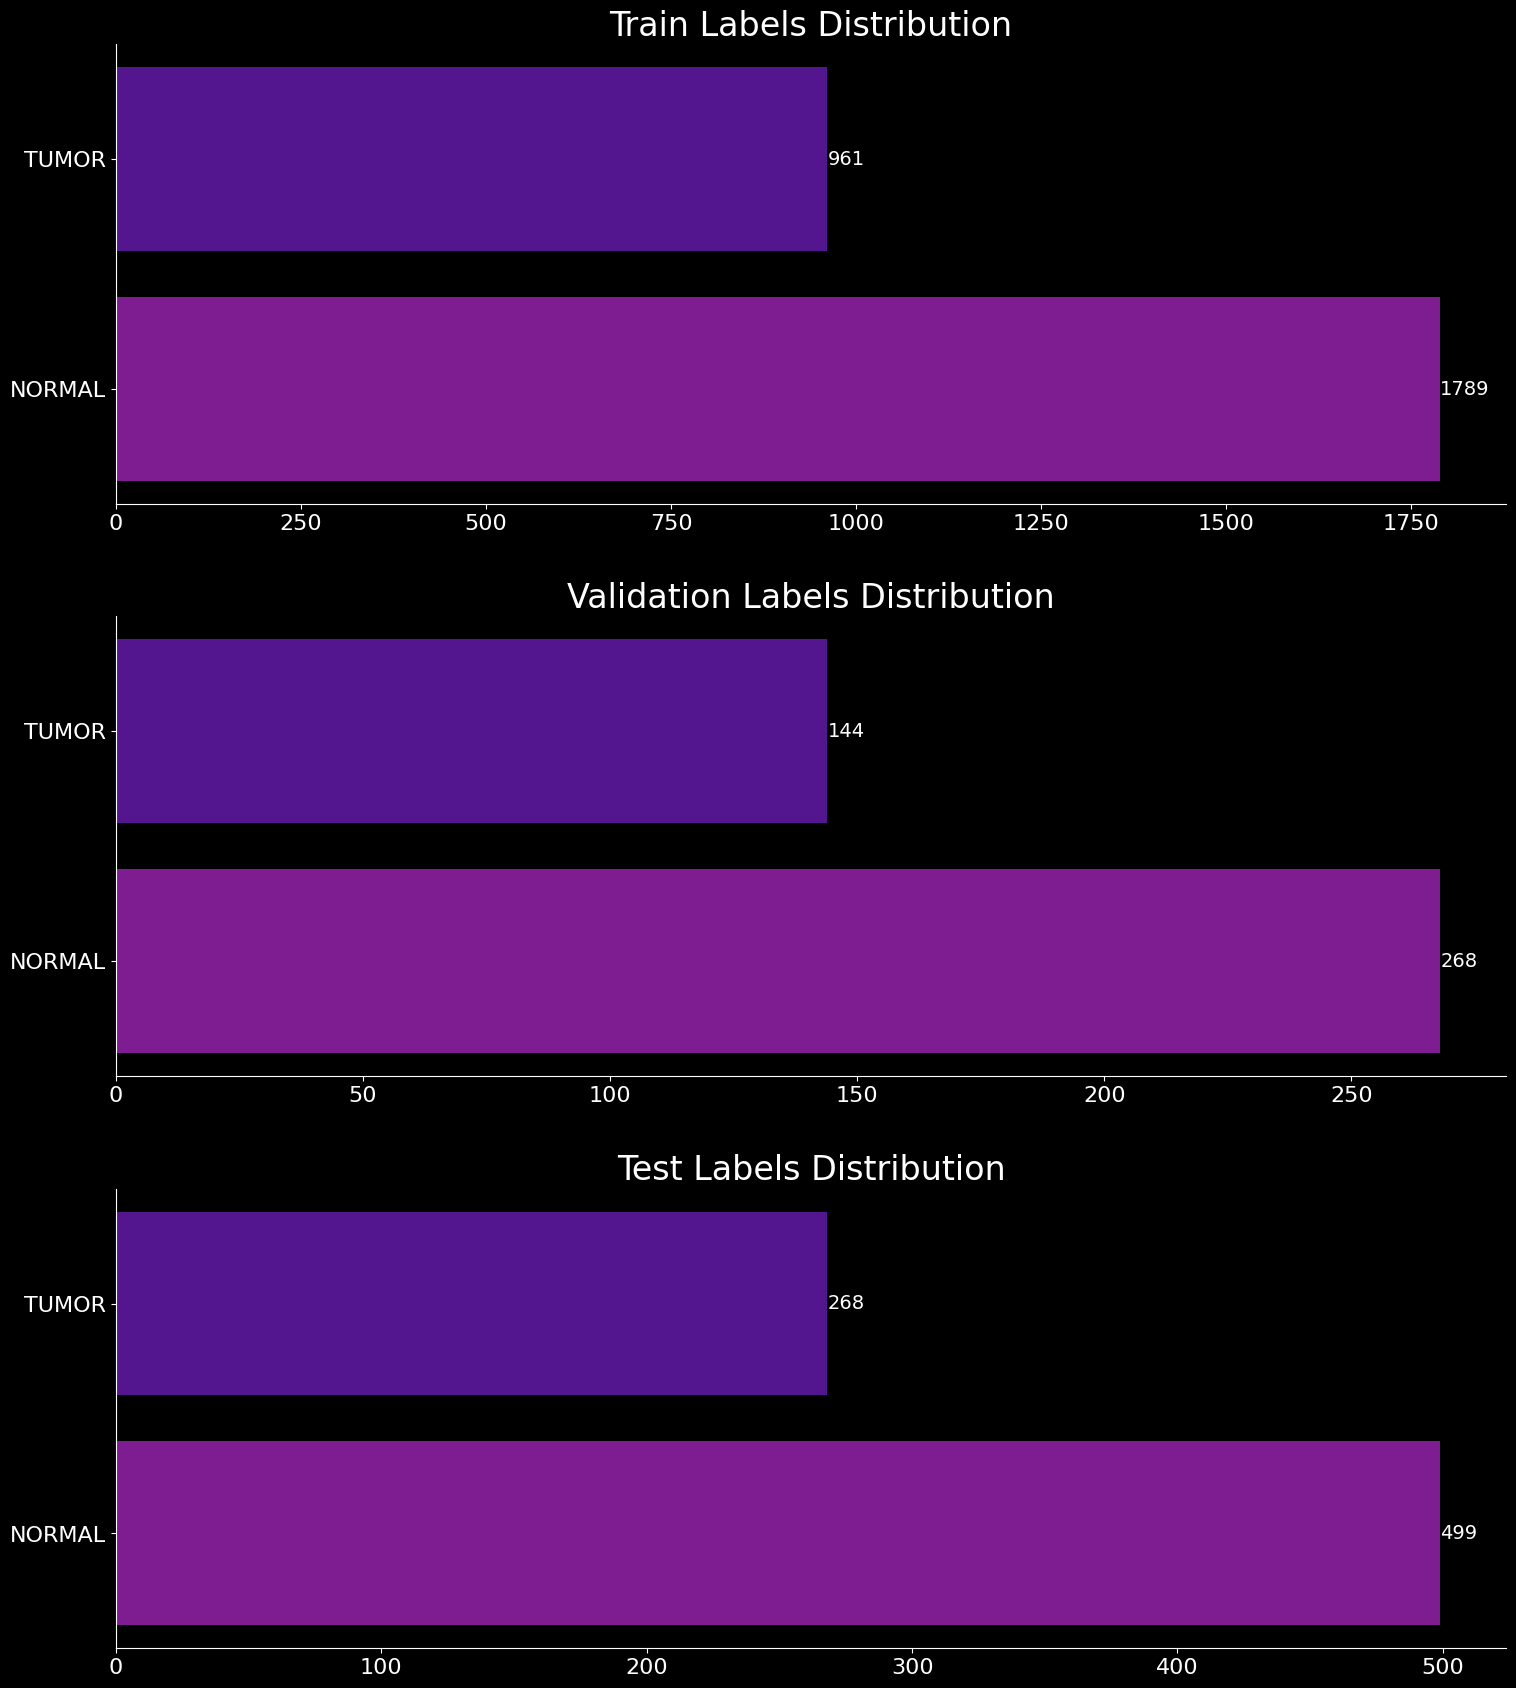

In [27]:
fig, (ax1, ax2, ax3) = plt.subplots(3, figsize=(16, 18))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)
sns.despine();


# Plot Train Labels Distribution
ax1.set_title('Train Labels Distribution', fontsize=24)
train_distribution = train_df['diagnosis'].value_counts().sort_values()
labels = {0: 'NORMAL', 1: 'TUMOR'}
bar_plot = sns.barplot(
    x=train_distribution.values,
    y=[labels[_] for _ in train_distribution.keys()],
    orient="h", palette=sns.color_palette("plasma"),
    ax=ax1
);

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.0f', fontsize=14);

# Update axes tick parameters
ax1.tick_params(
    axis='both', which='major',
    labelsize=16
);

# Plot Validation Labels Distribution
ax2.set_title('Validation Labels Distribution', fontsize=24)
val_distribution = val_df['diagnosis'].value_counts().sort_values()

bar_plot = sns.barplot(
    x=val_distribution.values,
    y=[labels[_] for _ in val_distribution.keys()],
    orient="h", palette=sns.color_palette("plasma"),
    ax=ax2
);

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.0f', fontsize=14);

# Update axes tick parameters
ax2.tick_params(
    axis='both', which='major',
    labelsize=16
);

# Plot Test Labels Distribution
ax3.set_title('Test Labels Distribution', fontsize=24)
test_distribution = test_df['diagnosis'].value_counts().sort_values()

bar_plot = sns.barplot(
    x=test_distribution.values,
    y=[labels[_] for _ in test_distribution.keys()],
    orient="h", palette=sns.color_palette("plasma"),
    ax=ax3
);

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.0f', fontsize=14);

# Update axes tick parameters
ax3.tick_params(
    axis='both', which='major',
    labelsize=16
);

In [28]:
# Augment train data
train_transforms = A.Compose([
    A.Resize(CFG.HEIGHT, CFG.WIDTH, p=1.0),
    A.RandomBrightnessContrast(p=0.2),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    ToTensorV2(),
])

# Only reshape inference data
inference_transforms = A.Compose([
    A.Resize(CFG.HEIGHT, CFG.WIDTH, p=1.0),
    ToTensorV2(),
])

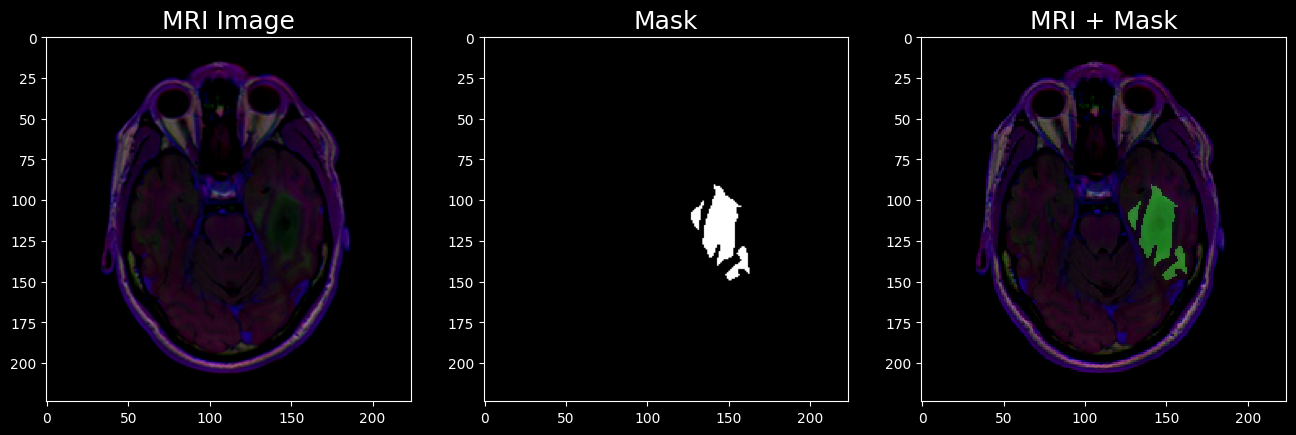

In [29]:
# Select random sample from train_df
idx = random.sample(ds.index.to_list(), 1)[0]

# Load the random sample and label
sample_image, sample_mask = _load(ds.image_path[idx]), _load(ds.mask_path[idx])

aug = train_transforms(image=sample_image, mask=sample_mask)

# View the random sample
view_sample(
    aug['image'].permute(1, 2, 0),
    aug['mask'].unsqueeze_(0).permute(1, 2, 0),
    color_map='mako',
)

In [30]:
class MRISegmetationDataset(Dataset):
    def __init__(self, df:pd.DataFrame, transform=None) -> None:
        super().__init__()

        self.mri_paths = df['image_path'].to_list()
        self.mask_paths = df['mask_path'].to_list()
        self.transform = transform

    def load_sample(self, index:str) -> Image.Image:
        image_path = self.mri_paths[index]
        mask_path = self.mask_paths[index]

        image, mask = Image.open(image_path), Image.open(mask_path)

        image = np.array(image).astype(np.float32) / 255.
        mask = np.array(mask).astype(np.float32) / 255.

        return image, mask

    def __len__(self) -> int:
        return self.mri_paths.__len__()

    def __getitem__(self, index:int) -> Tuple[torch.Tensor, torch.Tensor]:
        image, mask = self.load_sample(index)

        # Transform if necessary
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            return transformed['image'], transformed['mask'].unsqueeze_(0)
        else:
            transformed = ToTensorV2()(image=image, mask=mask)
            return transformed['image'], transformed['mask'].unsqueeze_(0)

In [31]:
# Build train dataset
train_ds = MRISegmetationDataset(
    train_df, transform=train_transforms
)

# Build validation dataset
val_ds = MRISegmetationDataset(
    val_df, transform=inference_transforms
)

# Build test dataset
test_ds = MRISegmetationDataset(
    test_df, transform=inference_transforms
)

In [32]:
# Build train dataloader
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=CFG.BATCH_SIZE,
    num_workers=CFG.NUM_WORKERS,
    shuffle=CFG.APPLY_SHUFFLE
)

# Build validation dataloader
val_loader = DataLoader(
    dataset=val_ds,
    batch_size=CFG.BATCH_SIZE,
    num_workers=CFG.NUM_WORKERS,
    shuffle=False
)

# Build test dataloader
test_loader = DataLoader(
    dataset=test_ds,
    batch_size=CFG.BATCH_SIZE,
    num_workers=CFG.NUM_WORKERS,
    shuffle=False
)

In [33]:
def execute_epoch(
    model:torch.nn.Module,
    dataloader:torch.utils.data.DataLoader,
    optimizer:torch.optim.Optimizer,
    loss_fn:torch.nn.Module,
    device:torch.device) -> Tuple[float, float]:

    # Set model into training mode
    model.train()

    # Initialize train loss & accuracy
    train_loss, train_dice = 0, 0

    # Execute training loop over train dataloader
    for batch, (X, y) in enumerate(dataloader):
        # Load data onto target device
        X, y = X.to(device), y.to(device)

        # Feed-forward and compute metrics
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # Reset Gradients & Backpropagate Loss
        optimizer.zero_grad()
        loss.backward()

        # Update Model Gradients
        optimizer.step()

        # Compute Batch Metrics
        predicted_class = torch.sigmoid(y_pred)
        predicted_class = (predicted_class > 0.5).float()

        eps = 1e-8
        train_dice += (
            (2 * (y * predicted_class).sum() + eps) /
            ((y + predicted_class).sum() + eps)
        ).cpu().item()


    # Compute Step Metrics
    train_loss = train_loss / len(dataloader)
    train_dice = train_dice / len(dataloader)

    return train_loss, train_dice

In [34]:
def evaluate(
    model:torch.nn.Module,
    dataloader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    device:torch.device) -> Tuple[float, float]:

    # Set model into eval mode
    model.eval()

    # Initialize eval loss & accuracy
    eval_loss, eval_dice = 0, 0

    # Active inferene context manager
    with torch.inference_mode():
        # Execute eval loop over dataloader
        for batch, (X, y) in enumerate(dataloader):
            # Load data onto target device
            X, y = X.to(device), y.to(device)

            # Feed-forward and compute metrics
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            eval_loss += loss.item()

            # Compute Batch Metrics
            predicted_class = torch.sigmoid(y_pred)
            predicted_class = (predicted_class > 0.5).float()

            eps = 1e-8
            eval_dice += (
                (2 * (y * predicted_class).sum() + eps) /
                ((y + predicted_class).sum() + eps)
            ).cpu().item()

    # Compute Step Metrics
    eval_loss = eval_loss / len(dataloader)
    eval_dice = eval_dice / len(dataloader)

    return eval_loss, eval_dice

In [35]:
def train(
    model:torch.nn.Module,
    train_dataloader:torch.utils.data.DataLoader,
    eval_dataloader:torch.utils.data.DataLoader,
    optimizer:torch.optim.Optimizer,
    scheduler:torch.optim.lr_scheduler,
    loss_fn:torch.nn.Module,
    epochs:int,
    device:torch.device) -> Dict[str, List]:

    # Initialize training session
    session = {
        'loss'            : [],
        'dice_score'      : [],
        'eval_loss'       : [],
        'eval_dice_score' : []
    }

    # Training loop
    for epoch in tqdm(range(epochs)):
        # Execute Epoch
        print(f'\nEpoch {epoch + 1}/{epochs}')
        train_loss, train_dice = execute_epoch(
            model,
            train_dataloader,
            optimizer,
            loss_fn,
            device
        )

        # Evaluate Model
        eval_loss, eval_dice = evaluate(
            model,
            eval_dataloader,
            loss_fn,
            device
        )

        # Execute schedular step
        current_lr = 0
        if scheduler:
            scheduler.step(eval_loss)
            current_lr = optimizer.param_groups[0]['lr']

        # Log Epoch Metrics
        log_text = f'loss: {train_loss:.4f} - dice_score: {train_dice:.4f} - eval_loss: {eval_loss:.4f} - eval_dice_score: {eval_dice:.4f}'

        if scheduler:
            print(log_text + f' - lr: {current_lr}')
        else:
            print(log_text)

        # Record Epoch Metrics
        session['loss'].append(train_loss)
        session['dice_score'].append(train_dice)
        session['eval_loss'].append(eval_loss)
        session['eval_dice_score'].append(eval_dice)

    # Return Session Metrics
    return session

In [36]:
def predict(
    model:nn.Module,
    sample_loader:torch.utils.data.DataLoader,
    device:torch.device,
    threshold:float=0.5) -> np.ndarray:

    # Set model into eval mode
    model.eval()

    predictions = []

    # Active inferene context manager
    with torch.inference_mode():
        # Execute eval loop over dataloader
        for batch, (X, y) in enumerate(tqdm(sample_loader)):
            # Load data onto target device
            X, y = X.to(device), y.to(device)

            # Feed-forward and compute metrics
            y_pred = model(X)

            # Compute Batch Metrics
            predicted_class = torch.sigmoid(y_pred)
            predicted_class = (predicted_class >= threshold).float()

            # Record prediction
            predictions.append(predicted_class.cpu().numpy())

    return np.vstack(predictions)

In [37]:
class DoubleConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConvBlock, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1,
            padding=1, bias=False
        )

        self.batchnorm1 = nn.BatchNorm2d(out_channels)
        self.batchnorm2 = nn.BatchNorm2d(out_channels)

        self.relu1 = nn.ReLU(inplace=True)
        self.relu2 = nn.ReLU(inplace=True)


    def forward(self, x):
        # First Convolution
        x = self.conv1(x)
        x = self.batchnorm1(x)
        x = self.relu1(x)

        # Second Convolution
        x = self.conv2(x)
        x = self.batchnorm2(x)

        return self.relu2(x)

In [38]:
class UNetModel(nn.Module):
    def __init__(
        self, in_channels:int=3,
        out_channels:int=1,
        block_sizes:Tuple[int]=(64, 128, 256, 512)
    ):
        super(UNetModel, self).__init__()

        # Initialise model encoder & decoder using torch ModuleLists
        self.encoder, self.decoder = nn.ModuleList(), nn.ModuleList()
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Create Encoder
        for block_size in block_sizes:
            self.encoder.append(DoubleConvBlock(in_channels, block_size))
            in_channels = block_size

        # Create Decoder
        for block_size in block_sizes[::-1]:
            self.decoder.append(
                nn.ConvTranspose2d(2 * block_size, block_size, kernel_size=2, stride=2)
            )
            self.decoder.append(DoubleConvBlock(2 * block_size, block_size))

        # Create Bottleneck
        last_blocksize = block_sizes[-1]
        self.bottleneck = DoubleConvBlock(last_blocksize, 2 * last_blocksize)

        # Create Output Layer
        self.output_conv = nn.Conv2d(block_sizes[0], out_channels, kernel_size=1)

    def forward(self, x):
        concatenations = []
        concatenations.append(x)

        # Propagate input downstream (Encode Input)
        for encoder_layer in self.encoder:
            x = encoder_layer(x)
            concatenations.append(x)
            x = self.max_pool(x)

        # Execute bottleneck
        x = self.bottleneck(x)
        concatenations = concatenations[::-1]

        # Propagate input upstream (Decode Input) & concatenate layers
        for _ in range(0, len(self.decoder), 2):
            x = self.decoder[_](x)
            encoder_layer = concatenations[_ // 2]

            # Concatenate corrensponding encoder layer to decoder layer output
            concat_layer = torch.cat(
                (encoder_layer, x), dim=1
            )

            x = self.decoder[_ + 1](concat_layer)

        # Return predicted logits
        return self.output_conv(x)

In [39]:
# Define U-Net Params
unet_params = {
    'in_channels'    : 3,
    'out_channels'   : 1,
    'block_sizes'    : (64, 128, 256, 512)
}

# Generate Model & Push to Device
unet_model = UNetModel(**unet_params).to(CFG.DEVICE)

# If using GPU T4 x2 setup, use this:
if CFG.NUM_DEVICES > 1:
    unet_model = nn.DataParallel(unet_model)

In [40]:
# View model summary
summary(
    model=unet_model,
    input_size=(CFG.BATCH_SIZE, CFG.CHANNELS, CFG.WIDTH, CFG.HEIGHT),
    col_names=["output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Output Shape         Param #              Trainable
UNetModel (UNetModel)                    [32, 1, 224, 224]    --                   True
├─ModuleList (encoder)                   --                   (recursive)          True
│    └─DoubleConvBlock (0)               [32, 64, 224, 224]   --                   True
│    │    └─Conv2d (conv1)               [32, 64, 224, 224]   1,728                True
│    │    └─BatchNorm2d (batchnorm1)     [32, 64, 224, 224]   128                  True
│    │    └─ReLU (relu1)                 [32, 64, 224, 224]   --                   --
│    │    └─Conv2d (conv2)               [32, 64, 224, 224]   36,864               True
│    │    └─BatchNorm2d (batchnorm2)     [32, 64, 224, 224]   128                  True
│    │    └─ReLU (relu2)                 [32, 64, 224, 224]   --                   --
├─MaxPool2d (max_pool)                   [32, 64, 112, 112]   --                   --
├─ModuleList (encoder)           

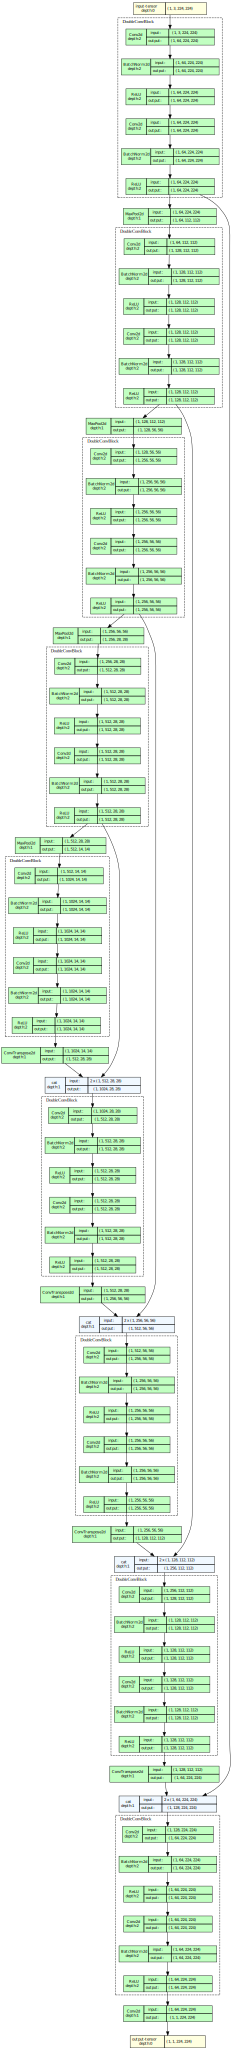

In [41]:
# Generate Model Computation Graph
model_graph = draw_graph(
    UNetModel(),
    input_size=(1, CFG.CHANNELS, CFG.WIDTH, CFG.HEIGHT),
    expand_nested=True
)

# View Model Architecture
model_graph.visual_graph

In [42]:
# Define Loss Function
loss_fn = nn.BCEWithLogitsLoss()

# Define Optimizer
optimizer = torch.optim.AdamW(
    unet_model.parameters(),
    lr=CFG.LR
)

# Define Scheduler
scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer=optimizer,
    mode='min',
    patience=CFG.PATIENS
)

In [43]:
print('Training U-Net Model')
print(f'Train on {len(train_df)} samples, validate on {len(val_df)} samples.')
print('----------------------------------')

# Generate training session config
session_config = {
    'model'               : unet_model,
    'train_dataloader'    : train_loader,
    'eval_dataloader'     : val_loader,
    'optimizer'           : optimizer,
    'scheduler'           : scheduler,
    'loss_fn'             : loss_fn,
    'epochs'              : CFG.EPOCHS,
    'device'              : CFG.DEVICE
}

# Execute Training Session
unet_session_history = train(**session_config)

Training U-Net Model
Train on 2750 samples, validate on 412 samples.
----------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]


Epoch 1/100
loss: 0.3529 - dice_score: 0.2951 - eval_loss: 0.2586 - eval_dice_score: 0.5372 - lr: 0.0001

Epoch 2/100
loss: 0.2281 - dice_score: 0.4627 - eval_loss: 0.2090 - eval_dice_score: 0.5517 - lr: 0.0001

Epoch 3/100
loss: 0.1901 - dice_score: 0.5220 - eval_loss: 0.1855 - eval_dice_score: 0.5703 - lr: 0.0001

Epoch 4/100
loss: 0.1628 - dice_score: 0.5596 - eval_loss: 0.1513 - eval_dice_score: 0.6441 - lr: 0.0001

Epoch 5/100
loss: 0.1410 - dice_score: 0.6090 - eval_loss: 0.1343 - eval_dice_score: 0.6297 - lr: 0.0001

Epoch 6/100
loss: 0.1214 - dice_score: 0.6428 - eval_loss: 0.1118 - eval_dice_score: 0.7145 - lr: 0.0001

Epoch 7/100
loss: 0.1052 - dice_score: 0.6761 - eval_loss: 0.0976 - eval_dice_score: 0.7330 - lr: 0.0001

Epoch 8/100
loss: 0.0921 - dice_score: 0.7011 - eval_loss: 0.0861 - eval_dice_score: 0.7190 - lr: 0.0001

Epoch 9/100
loss: 0.0820 - dice_score: 0.7077 - eval_loss: 0.0783 - eval_dice_score: 0.7261 - lr: 0.0001

Epoch 10/100
loss: 0.0726 - dice_score: 0.732

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [46]:
# Create Model directory


model_name = 'unet_model'
model_path = '/content/drive/MyDrive/model/'
os.makedirs(model_path, exist_ok=True)

In [47]:
# Save Model
torch.save(unet_model, model_path + model_name + '.pth')

In [48]:
# Generate Test Masks
unet_test_masks = predict(
    unet_model, test_loader,
    CFG.DEVICE, threshold=0.5
)

  0%|          | 0/24 [00:00<?, ?it/s]

Performance Analysis

In [49]:
def plot_training_curves(history, fig_size=(20, 10)):

    loss = np.array(history['loss'])
    val_loss = np.array(history['eval_loss'])

    dice_coeff = np.array(history['dice_score'])
    val_dice_coeff = np.array(history['eval_dice_score'])

    epochs = range(len(history['loss']))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=fig_size)

    # Plot loss
    ax1.plot(epochs, loss, label='training_loss', marker='o', color='C5');
    ax1.plot(epochs, val_loss, label='eval_loss', marker='o', color='C6');

    # Fill area between losses
    ax1.fill_between(epochs, loss, val_loss, where=(loss > val_loss), color='C5', alpha=0.4, interpolate=True);
    ax1.fill_between(epochs, loss, val_loss, where=(loss < val_loss), color='C6', alpha=0.4, interpolate=True);

    # Add Text & Formats
    ax1.set_title('Loss (Lower Means Better)', fontsize=22);
    ax1.set_xlabel('Epochs', fontsize=18);
    ax1.set_ylabel('Loss', fontsize=18);
    ax1.tick_params(axis='both', which='major', labelsize=14);
    ax1.legend(fontsize=14);

    # Plot metric
    ax2.plot(epochs, dice_coeff, label='training_dice_score', marker='o', color='C5');
    ax2.plot(epochs, val_dice_coeff, label='eval_dice_score', marker='o', color='C6');

    # Fill area between metrics
    ax2.fill_between(epochs, dice_coeff, val_dice_coeff, where=(dice_coeff > val_dice_coeff), color='C5', alpha=0.4, interpolate=True);
    ax2.fill_between(epochs, dice_coeff, val_dice_coeff, where=(dice_coeff < val_dice_coeff), color='C6', alpha=0.4, interpolate=True);

    # Add Text & Formats
    ax2.set_title('Dice Score (Higher Means Better)', fontsize=22);
    ax2.set_xlabel('Epochs', fontsize=18);
    ax2.set_ylabel('Dice Score', fontsize=18);
    ax2.tick_params(axis='both', which='major', labelsize=14);
    ax2.legend(fontsize=14);

    sns.despine();

    return

In [50]:
# Convert U-Net history dict to DataFrame
unet_session_history_df = pd.DataFrame(unet_session_history)
unet_session_history_df

,loss,dice_score,eval_loss,eval_dice_score
0,0.352871,0.295115,0.258617,0.537151
1,0.228095,0.462687,0.208959,0.551698
2,0.190073,0.522046,0.185493,0.570321
3,0.162762,0.559615,0.151298,0.644066
4,0.141009,0.608957,0.134253,0.629735
...,...,...,...,...
95,0.003897,0.924986,0.005210,0.904073
96,0.003988,0.923461,0.005195,0.903168
97,0.003869,0.926348,0.005188,0.903600
98,0.003856,0.926125,0.005188,0.905049


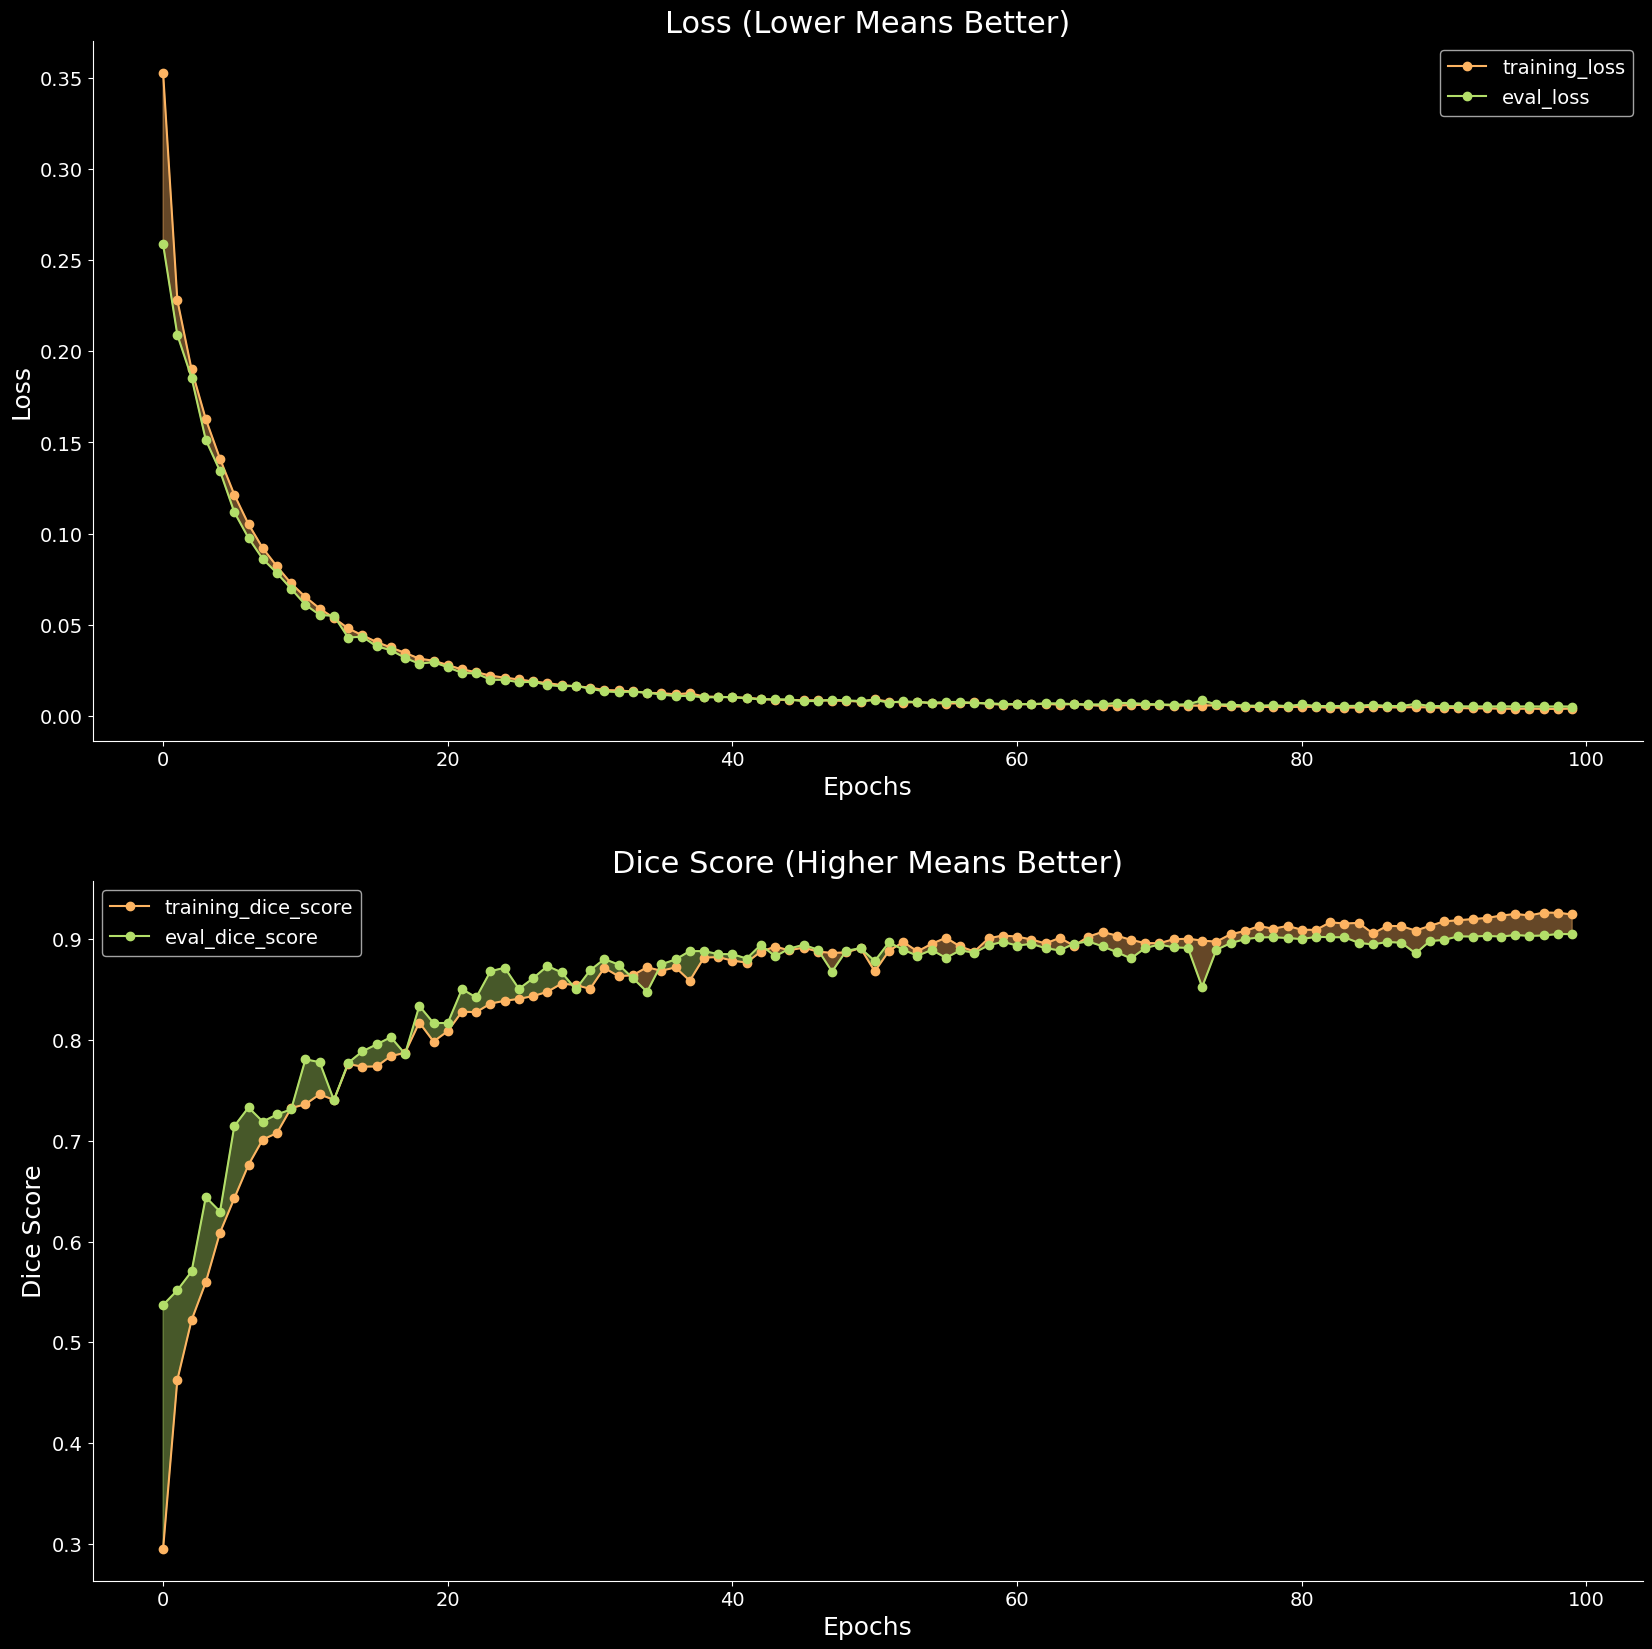

In [51]:
# Plot U-Net Session Training History
plot_training_curves(
    unet_session_history,
    fig_size=(20, 20)
)

In [52]:
# def accuracy(y_true, y_pred):
#     intersection = (y_true * y_pred).sum()
#     union = (y_true + y_pred).sum() - intersection
#     xor = (y_true == y_pred).sum()

#     return (xor / (union + xor - intersection))


def precision_(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    total_predicted_pixels = y_pred.sum()
    return (intersection / total_predicted_pixels).mean()


def recall_(y_true, y_pred):
    intersection = (y_true * y_pred).sum()
    total_true_pixels = y_true.sum()
    return (intersection / total_true_pixels).mean()


def dice_score(y_true, y_pred):
    eps = 1e-8
    intersection = (y_true * y_pred).sum()
    summation = (y_true + y_pred).sum()

    return ((2 * intersection) / (summation + eps))


def jaccard_index(y_true, y_pred):
    eps = 1e-8
    intersection = (y_true * y_pred).sum()
    union = (y_true + y_pred).sum() - intersection

    return (intersection / (union + eps))

In [53]:
def compute_metrics(
    model:nn.Module,
    sample_loader:torch.utils.data.DataLoader,
    device:torch.device) -> np.ndarray:

    # Initiate Metrics Dict
    metrics = {
        'accuracy'      : [],
        'precision'     : [],
        'recall'        : [],
        'dice_score'    : [],
        'IoU'           : []
    }

    # Set model into eval mode
    model.eval()

    # Active inferene context manager
    with torch.inference_mode():
        # Execute eval loop over dataloader
        for batch, (X, y) in enumerate(tqdm(sample_loader)):
            # Load data onto target device
            X, y = X.to(device), y.to(device)

            # Feed-forward Input
            y_pred = model(X)

            # Generate Predicted Masks
            predicted_class = torch.sigmoid(y_pred)
            predicted_class = (predicted_class > 0.3).float()

            # Compute Batch Metrics For Each Mask
            for true_mask, pred_mask in zip(y, predicted_class):
                acc = ((true_mask == pred_mask).sum() / torch.numel(true_mask)).cpu().item()
                prec = precision_(true_mask, pred_mask).cpu().item()
                rec = recall_(true_mask, pred_mask).cpu().item()
                dice = dice_score(true_mask, pred_mask).cpu().item()
                iou = jaccard_index(true_mask, pred_mask).cpu().item()

                # Record metrics
                metrics['accuracy'].append(acc)
                metrics['precision'].append(prec)
                metrics['recall'].append(rec)
                metrics['dice_score'].append(dice)
                metrics['IoU'].append(iou)

    return metrics

In [54]:
# Generate Segmentation Metrics
unet_metrics = compute_metrics(
    unet_model, test_loader, CFG.DEVICE
)

  0%|          | 0/24 [00:00<?, ?it/s]

In [55]:
# Create copy of test df
unet_test_df = test_df.copy()

# Concatenate Metrics onto copied df
unet_test_df = pd.concat(
    (unet_test_df, pd.DataFrame(unet_metrics)),
    axis=1
)

# Generate diagnosis labels
unet_test_df['model_diagnosis'] = [
    int(mask.max()) for mask in unet_test_masks
]

# View df
unet_test_df

,id,patient,image_path,mask_path,diagnosis,accuracy,precision,recall,dice_score,IoU,model_diagnosis
0,22,TCGA_DU_A5TS_19970726,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,0.997250,0.747104,0.982234,0.848684,0.737143,1
1,11,TCGA_DU_8165_19970205,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,1.000000,NaN,NaN,0.000000,0.000000,0
2,58,TCGA_HT_7881_19981015,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,1.000000,NaN,NaN,0.000000,0.000000,0
3,19,TCGA_DU_5853_19950823,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,1.000000,NaN,NaN,0.000000,0.000000,0
4,1,TCGA_DU_7298_19910324,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,1.000000,NaN,NaN,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...
762,29,TCGA_DU_6399_19830416,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,0.998266,0.864238,0.990512,0.923077,0.857143,1
763,4,TCGA_DU_7294_19890104,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,1.000000,NaN,NaN,0.000000,0.000000,0
764,11,TCGA_HT_8105_19980826,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,1.000000,NaN,NaN,0.000000,0.000000,0
765,22,TCGA_DU_7014_19860618,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,0.997708,0.709677,0.747573,0.728132,0.572491,1


In [56]:
# Get segmentation metrics for all samples
overall_metrics = dict(
    unet_test_df[unet_metrics.keys()]
    .mean()
)

# Get segmentation metrics for non-diagnosed samples
non_diagnosed_metrics = dict(
    unet_test_df[
        unet_test_df['diagnosis'] == 0
    ][unet_metrics.keys()].mean()
)

# Get segmentation metrics for diagnosed samples
diagnosed_metrics = dict(
    unet_test_df[
        unet_test_df['diagnosis'] == 1
    ][unet_metrics.keys()].mean()
)

# Compile metrics into dataframe
segmetation_metrics = pd.DataFrame({
    'overall_metrics': overall_metrics,
    'non_diagnosed_metrics': non_diagnosed_metrics,
    'diagnosed_metrics': diagnosed_metrics,
}).T

# View segmetation metrics df
segmetation_metrics

,accuracy,precision,recall,dice_score,IoU
overall_metrics,0.998035,0.810004,0.887684,0.296143,0.267419
non_diagnosed_metrics,0.999829,0.000000,NaN,0.000000,0.000000
diagnosed_metrics,0.994696,0.856735,0.887684,0.847543,0.765336


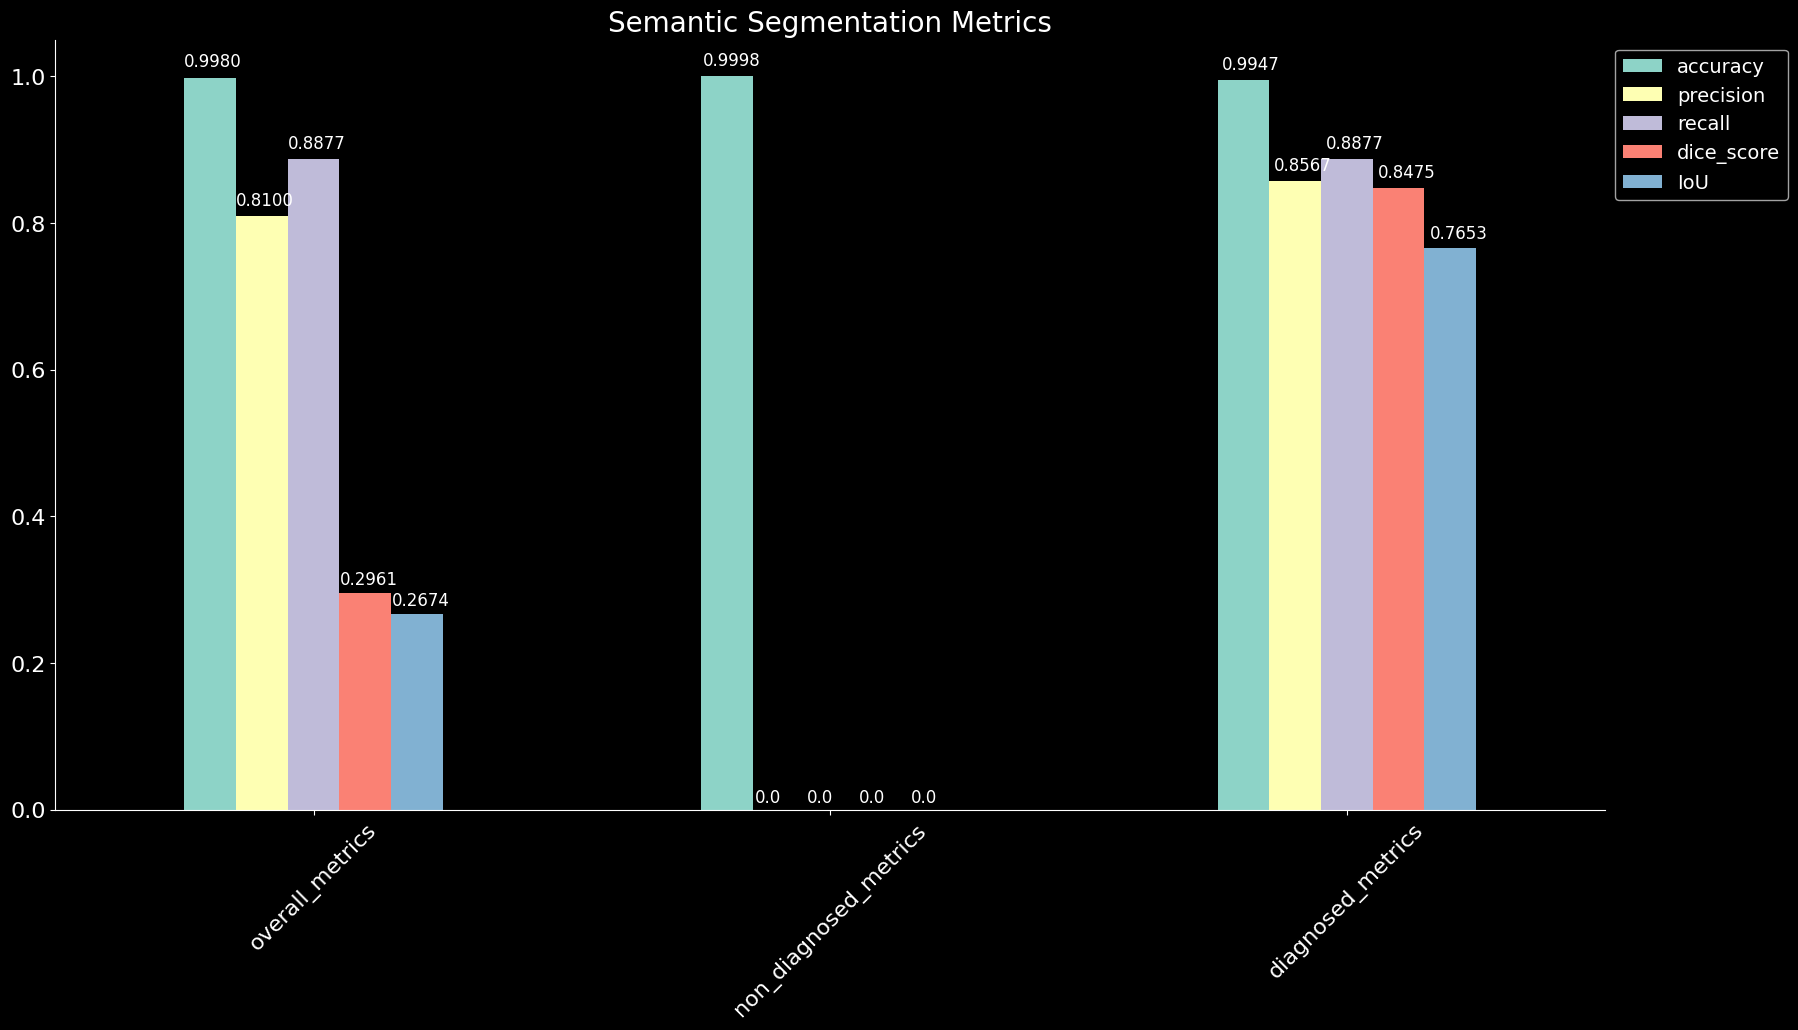

In [57]:
# Plot segmentation metrics bar plot
ax = segmetation_metrics.plot(
    kind="bar", rot=0,
    figsize=(20, 10)
)

# Add legend
ax.legend(bbox_to_anchor=(1.0, 1.0), fontsize=14)

# Display bar values
for p in ax.patches:
    bar_value = p.get_height()
    text = '0.0' if bar_value==0 else f'{bar_value:.4f}'
    ax.annotate(
        text,
        (p.get_x() * 1.005, p.get_height() * 1.005 + 0.01),
        fontsize=12
    )

# Update axes tick parameters
ax.tick_params(
    axis='both', which='major',
    labelsize=16
);

# Rotate x-axis ticks
ax.tick_params(
    axis='x', which='major',
    labelsize=16, rotation=45
);

# Add title & remove top and right borders w. sns.despine
plt.title('Semantic Segmentation Metrics', fontsize=20);
sns.despine();

In [60]:
def plot_confusion_matrix(y_true, y_pred, classes='auto', figsize=(10, 10), text_size=12):
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Set plot size
    plt.figure(figsize=figsize)

    # Create confusion matrix heatmap
    disp = sns.heatmap(
        cm, annot=True, cmap='Greens',
        annot_kws={"size": text_size}, fmt='g',
        linewidths=0.5, linecolor='black', clip_on=False,
        xticklabels=classes, yticklabels=classes)

    # Set title and axis labels
    disp.set_title('Confusion Matrix', fontsize=24)
    disp.set_xlabel('Predicted Label', fontsize=20)
    disp.set_ylabel('True Label', fontsize=20)
    plt.yticks(rotation=0)

    # Plot confusion matrix
    plt.show()

    return

In [61]:
# Get Test True Diagnosis Labels
test_labels = unet_test_df['diagnosis'].to_numpy()

# Get Test Predicted Diagnosis Labels
unet_predictions = unet_test_df['model_diagnosis'].to_numpy()

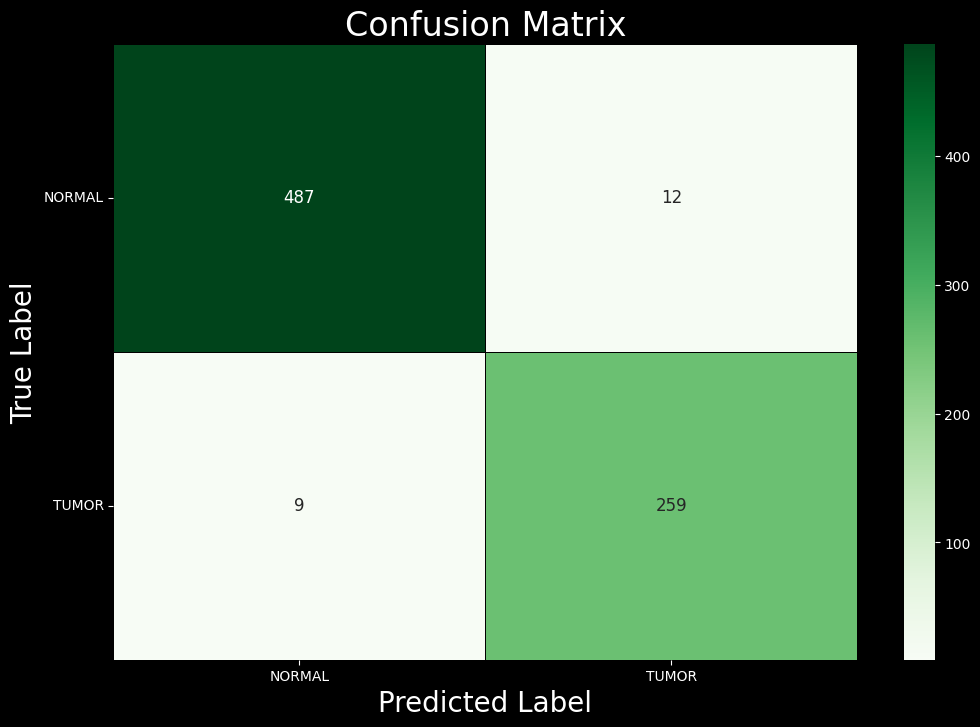

In [62]:
# Plot Confusion Matrix
plot_confusion_matrix(
    test_labels,
    unet_predictions,
    figsize=(12, 8),
    classes=['NORMAL', 'TUMOR']
)

In [63]:
print(
    classification_report(
        test_labels,
        unet_predictions,
        target_names=['NORMAL', 'TUMOR']
))

              precision    recall  f1-score   support

      NORMAL       0.98      0.98      0.98       499
       TUMOR       0.96      0.97      0.96       268

    accuracy                           0.97       767
   macro avg       0.97      0.97      0.97       767
weighted avg       0.97      0.97      0.97       767



In [64]:
def generate_performance_scores(y_true, y_pred, log=True):

    model_accuracy = accuracy_score(y_true, y_pred)
    model_precision, model_recall, model_f1, _ = (
        precision_recall_fscore_support(
            y_true, y_pred, average="weighted"
        )
    )
    model_matthews_corrcoef = matthews_corrcoef(y_true, y_pred)

    if log:
        print('=============================================')
        print(f'\nPerformance Metrics:\n')
        print('=============================================')
        print(f'accuracy_score:\t\t{model_accuracy:.4f}\n')
        print('_____________________________________________')
        print(f'precision_score:\t{model_precision:.4f}\n')
        print('_____________________________________________')
        print(f'recall_score:\t\t{model_recall:.4f}\n')
        print('_____________________________________________')
        print(f'f1_score:\t\t{model_f1:.4f}\n')
        print('_____________________________________________')
        print(f'matthews_corrcoef:\t{model_matthews_corrcoef:.4f}\n')
        print('=============================================')

    preformance_scores = {
        'accuracy_score'       : model_accuracy,
        'precision_score'      : model_precision,
        'recall_score'         : model_recall,
        'f1_score'             : model_f1,
        'matthews_corrcoef'    : model_matthews_corrcoef
    }
    return preformance_scores

In [65]:
# Generate U-Net model classification performance scores
unet_model_performance = generate_performance_scores(
    test_labels, unet_predictions, log=True
)


Performance Metrics:

accuracy_score:		0.9726

_____________________________________________
precision_score:	0.9727

_____________________________________________
recall_score:		0.9726

_____________________________________________
f1_score:		0.9727

_____________________________________________
matthews_corrcoef:	0.9400



In [69]:
def view_multiple_predictions(
    model, ds, count=10,
    color_map='rgb',
    fig_size=(14, 10),
    title_size=16):

    # Select random samples
    idx = random.sample(
        list(range(len(ds))),
        count
    )

    # Initialise figure
    fig = plt.figure(figsize=fig_size);
    fig.tight_layout();
    fig.subplots_adjust(top=0.95);

    # Plot Samples
    for row, _ in enumerate(idx):
        image, mask = ds[_]
        idx = 3 * (row + 1)

        # Plot MRI Image
        plt.subplot(count+1, 3, idx + 1);
        plt.title(f'MRI Image', fontsize=title_size);
        if color_map=='rgb':
            plt.imshow(image.permute(1, 2, 0))
        else:
            plt.imshow(image.permute(1, 2, 0), cmap=color_map)

        # Plot Mask
        plt.subplot(count+1, 3, idx + 2);
        plt.title(f'True Mask', fontsize=title_size)

        gen_mask = np.dstack([mask[0]*0.1, mask[0]*0.45, mask[0]*0.1])
        plt.imshow(image.permute(1, 2, 0) + gen_mask);

        # Generate predicted mask
        mri_input = torch.unsqueeze(
            torch.tensor(image), dim=0
        ).to(CFG.DEVICE)

        # Set inferene context manager to active for predictions
        with torch.inference_mode():
            pred_mask = model(mri_input)
            pred_mask = torch.sigmoid(pred_mask).cpu()
            pred_mask = (pred_mask > 0.5) #threshold of 0.5

        # Plot Predicted Mask
        plt.subplot(count+1, 3, idx + 3);
        plt.title(f'Predicted Mask', fontsize=title_size)

        pred_gen_mask = np.dstack([pred_mask[0][0]*0.3, pred_mask[0][0]*0.2, pred_mask[0][0]*0.8])
        plt.imshow(image.permute(1, 2, 0)+ pred_gen_mask);

    return

In [67]:
# Create Dataset for Diagnosed Sample
test_diagnosed_ds = MRISegmetationDataset(
    unet_test_df[
        unet_test_df['diagnosis'] == 1
    ].reset_index(drop=True),
    transform=inference_transforms
)

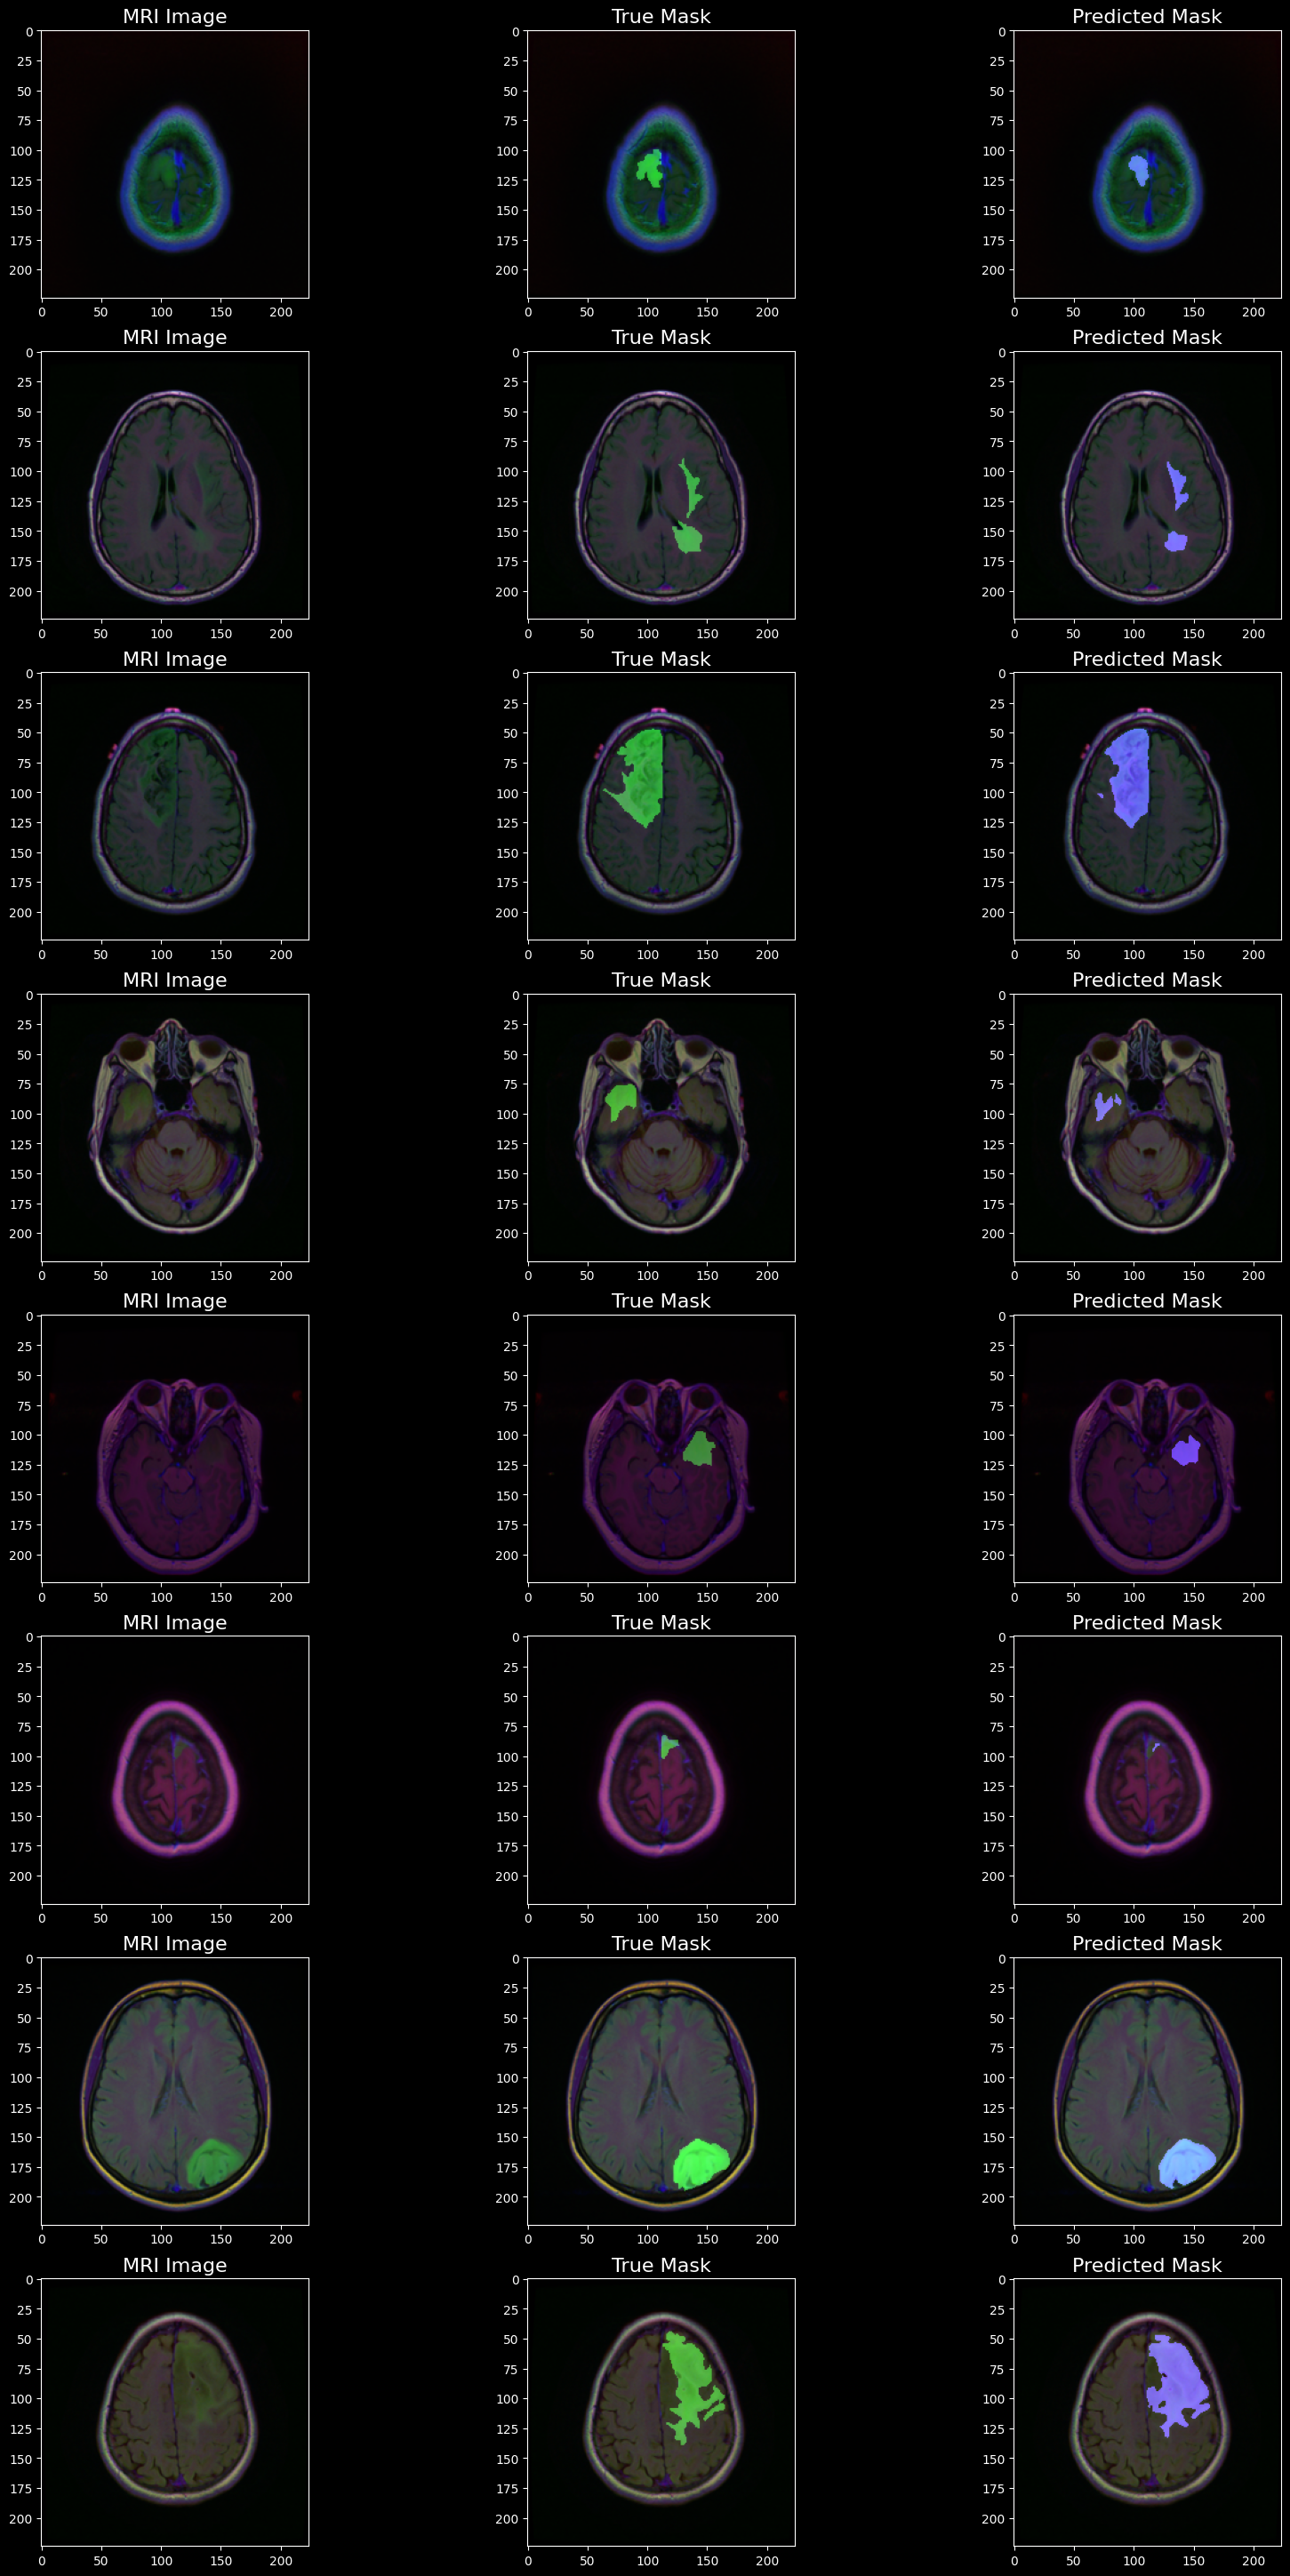

In [70]:
# View Random Samples
view_multiple_predictions(
    unet_model, test_diagnosed_ds,
    count=8, color_map='rgb',
    fig_size=(20, 38)
)